In [2]:
import os
import glob
import sys
import getpass
import importlib
from tqdm import tqdm
from pathlib import Path

# user path:
usrname = getpass.getuser()
# add paths:
sys.path.append(f'/Users/{usrname}/Desktop/Projects')
sys.path.append(f'/Users/{usrname}/Desktop/Projects/bimanual_wrist')
sys.path.append(f'/Users/{usrname}/Desktop/Projects/Functional_Fusion')
sys.path.append(f'/Users/{usrname}/Desktop/Projects/PcmPy')


import rsatoolbox as rsa
from rsatoolbox.io import spm as spm_io
import surfAnalysisPy as surf
import SUITPy as suit
import nibabel as nb
import nitools as nt
import PcmPy as pcm
import Functional_Fusion.atlas_map as am
import Functional_Fusion.reliability as rel

import matplotlib.pyplot as plt
import matplotlib
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import seaborn as sns

import scipy.stats as stats
import scipy
import scipy.io as sio
import numpy as np
import pandas as pd

import utils
importlib.reload(utils)

# SET PATHS:
baseDir = os.path.join('/Users', getpass.getuser(), 'Desktop', 'Projects', 'bimanual_wrist', 'data', 'fMRI')
bidsDir = 'BIDS'
anatomicalDir = 'anatomicals'
freesurferDir = 'surfaceFreesurfer'
surfacewbDir = 'surfaceWB' 
behavDir = 'behavioural'
regDir = 'ROI'
atlasDir = '/Volumes/diedrichsen_data$/data/Atlas_templates/fs_LR_32'
analysisDir = os.path.join(os.path.dirname(os.path.dirname(baseDir)), 'analysis')



## Within = eye

### Generate data with component model

here I generate data with components models. The components are plotted but a summary is: a hand effect, within contra, within ipsi, intrinsic relationship, and extrinsic relationship models.

The within component here is all assumed to be simply identity (conditions are orthogonal to each other).

In the following cells I simulate data under different weigths of the components and observe how the Pearson's correlation is effected.

#### intrinsic or extrinsic, perfect SNR

When only one type of relationship exists (either intrinsic or extrinsic), the existing one is correctly positive and high. The other correlation that should not exist is negative however. I think this is becaues the G matrix is double centered. So, always when one for example intrinsic has a high positive covariance, the other one becomes negative.

For example, in perfect SNR, when the intrinsic covariance is 1, the off-diagonal ones are -0.2, which is because each row and column is centered so has to be: 1 + 5x = 0 -> x = -1/5

"Can you just not remove the condition mean?" If you do not remove the mean, it does not fix the bias. If your activity patterns have mean of u_contra and u_ipsi, you'll get positive correlations between all contra and ipsi conditions. So, you will find both intrinsic and extrinsic are positively correlated. So removing the condition mean is inevitable. 

"But wait, don't we remove the mean of contra conditions separately and mean of ipsi condition separately? Then it is not trivial why the across contra-ipsi covariance should be affected by this mean removal?" That's exactly how we remove the mean. And that is why, if there was no relationship between contra and ipsi, we would see 0 Pearson's correlation. However, the moment these two become related in any ways (intrinsic, extrinsic, etc.) the correlations are not simply 0 anymore where you expected them to be. Again, due to same mean centering effect.

======== Intrinsic ========


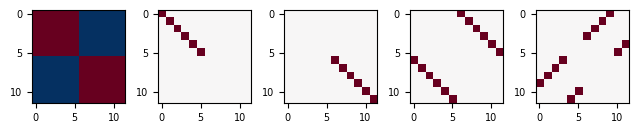

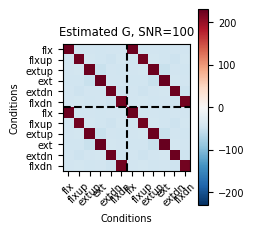

Intrinsic: mean=1.00 +/- 0.00
Extrinsic: mean=-0.20 +/- 0.01


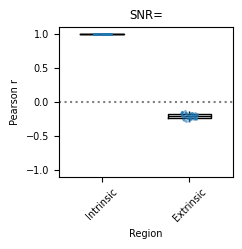

======== Extrinsic ========


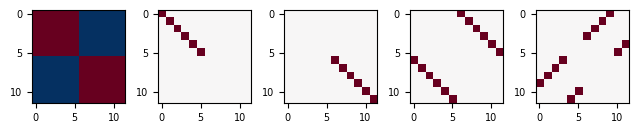

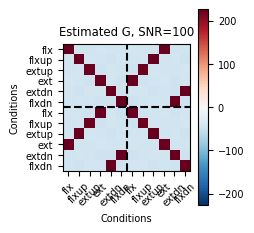

Intrinsic: mean=-0.20 +/- 0.00
Extrinsic: mean=1.00 +/- 0.00


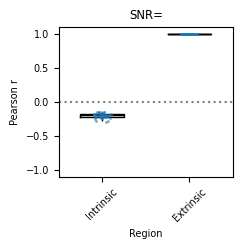

In [3]:
print('======== Intrinsic ========')
theta_true = np.array([-10e10,1,1,1,-10e10])
D, _ = utils.simulate.make_data_component_eye(sig=100, theta_true=theta_true, verbose=True)
_,_ = utils.simulate.pearson_r(D, verbose=True)

print('======== Extrinsic ========')
theta_true = np.array([-10e10,1,1,-10e10,1])
D, _ = utils.simulate.make_data_component_eye(sig=100, theta_true=theta_true, verbose=True)
_,_ = utils.simulate.pearson_r(D, verbose=True)


#### intrinsic or etrinsic, low snr

when SNR is low, the issue is still there but the correlations are very tiny.

======== Intrinsic ========


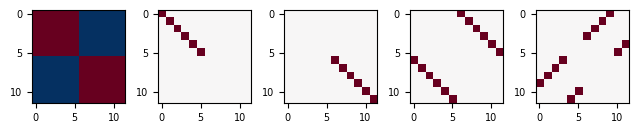

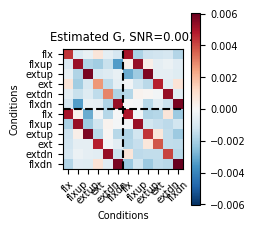

Intrinsic: mean=0.06 +/- 0.00
Extrinsic: mean=-0.01 +/- 0.00


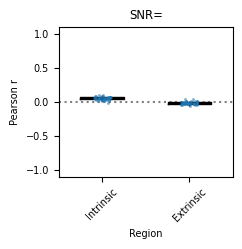

======== Extrinsic ========


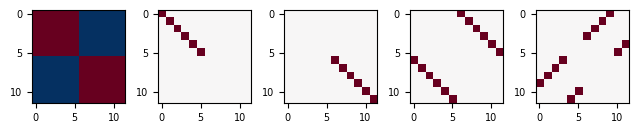

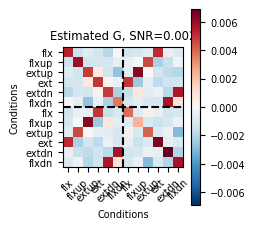

Intrinsic: mean=-0.01 +/- 0.00
Extrinsic: mean=0.06 +/- 0.00


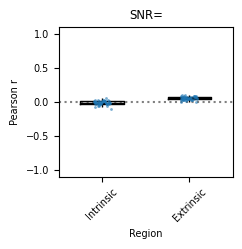

In [4]:
print('======== Intrinsic ========')
theta_true = np.array([-10e10,1,1,1,-10e10])
D, _ = utils.simulate.make_data_component_eye(sig=0.002, theta_true=theta_true, verbose=True)
_,_ = utils.simulate.pearson_r(D, verbose=True)

print('======== Extrinsic ========')
theta_true = np.array([-10e10,1,1,-10e10,1])
D, _ = utils.simulate.make_data_component_eye(sig=0.002, theta_true=theta_true, verbose=True)
_,_ = utils.simulate.pearson_r(D, verbose=True)


#### Both intrinsic + extrinsic equal weigths

good thing is, if both intrinsic and extrinsic relationhips exist with equal strength, we won't have that bias anymore. The problem starts when one relationship is much stronger than the other which you will find in the next cell.

======== perfect SNR ========


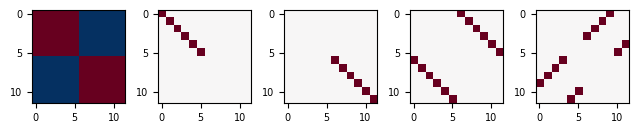

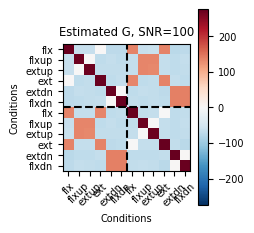

Intrinsic: mean=0.50 +/- 0.00
Extrinsic: mean=0.50 +/- 0.00


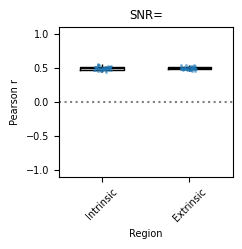

======== low SNR ========


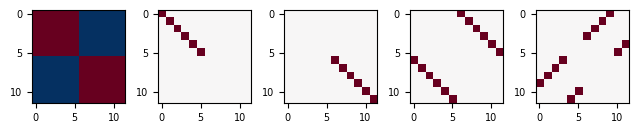

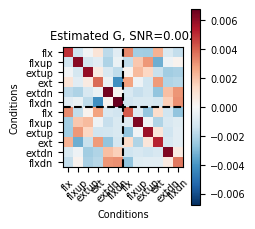

Intrinsic: mean=0.03 +/- 0.00
Extrinsic: mean=0.03 +/- 0.00


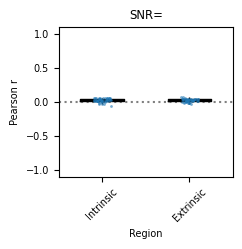

In [8]:
print('======== perfect SNR ========')
theta_true = np.array([-10e10,1,1,1,1])
D, _ = utils.simulate.make_data_component_eye(sig=100, theta_true=theta_true, verbose=True)
_,_ = utils.simulate.pearson_r(D, verbose=True)

print('======== low SNR ========')
theta_true = np.array([-10e10,1,1,1,1])
D, _ = utils.simulate.make_data_component_eye(sig=0.002, theta_true=theta_true, verbose=True)
_,_ = utils.simulate.pearson_r(D, verbose=True)


#### Both intrinsic + extrinsic but one is way stronger

now in this case, it becomes apparent how if one relationship is way stronger, the other one shows up as negative.

======== perfect SNR ========


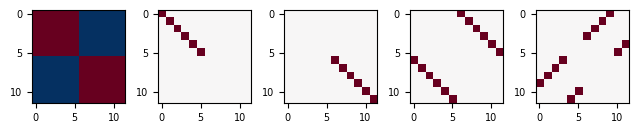

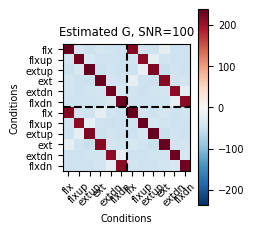

Intrinsic: mean=0.92 +/- 0.00
Extrinsic: mean=-0.09 +/- 0.01


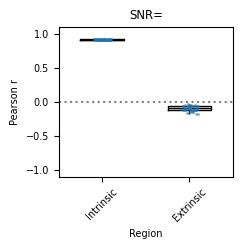

======== low SNR ========


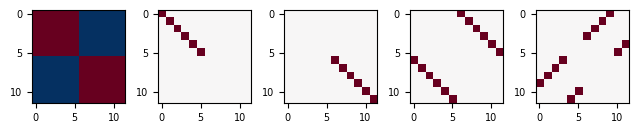

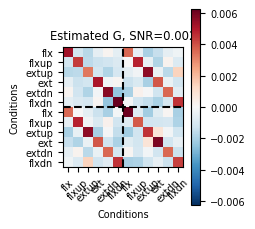

Intrinsic: mean=0.05 +/- 0.00
Extrinsic: mean=-0.01 +/- 0.00


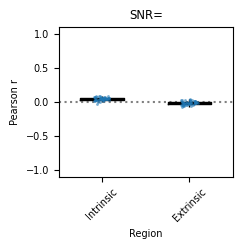

In [9]:
print('======== perfect SNR ========')
theta_true = np.array([-10e10,1,1,1,-1])
D, _ = utils.simulate.make_data_component_eye(sig=100, theta_true=theta_true, verbose=True)
_,_ = utils.simulate.pearson_r(D, verbose=True)

print('======== low SNR ========')
theta_true = np.array([-10e10,1,1,1,-1])
D, _ = utils.simulate.make_data_component_eye(sig=0.002, theta_true=theta_true, verbose=True)
_,_ = utils.simulate.pearson_r(D, verbose=True)


### Generate data with correlation model

here I am testing if the results and the model creation would be different if I generate data with a PCM correlation model.

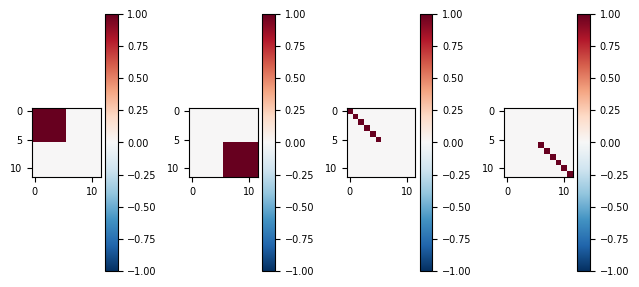

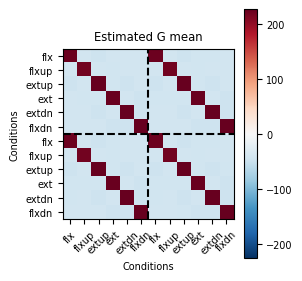

Intrinsic: mean=1.00 +/- 0.00
Extrinsic: mean=-0.20 +/- 0.01


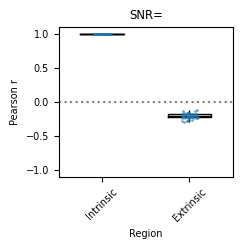

In [3]:
theta_true = np.array([-10e10,-10e10,1,1])
D, _ = utils.simulate.make_data_correlation_eye(sig=100, r=1, theta_true=theta_true, verbose=True)
_,_ = utils.simulate.pearson_r(D, verbose=True)


### CKA model

ok now we know that the Pearson's correlation and PCM correlation models will not be able to find the weaker correlation bc it will show up as negative. However, shouldn't we be able to find existence of extrinsic component using a CKA model. Here I test this idea in the following cells

#### Only intrinsic or extrinsic, Perfect SNR

here we only want to look at the weight of the different components. Note that you can't test these weights against 0 bc they are positive. But it gives some intution. 

So in case of high SNR, this works pretty nicely. Unless the hand component is added which leaks some variance to the other components.

======== Intrinsic ========


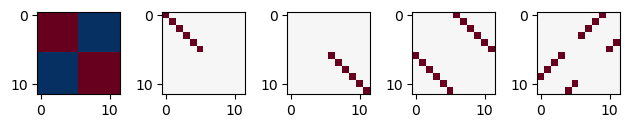

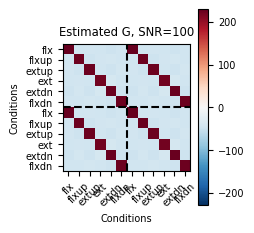

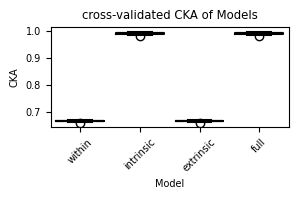

t-test intrinsic > within: t(49)=2255.950, p=0.0000
t-test extrinsic > within: t(49)=-27.933, p=1.0000
t-test full > intrinsic: t(49)=-528.099, p=1.0000
t-test full > extrinsic: t(49)=2255.956, p=0.0000


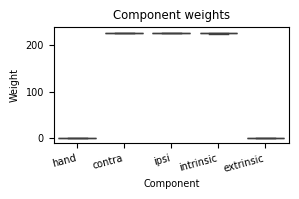

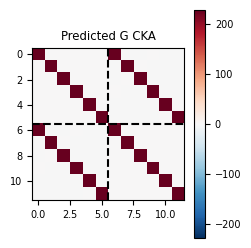

======== Extrinsic ========


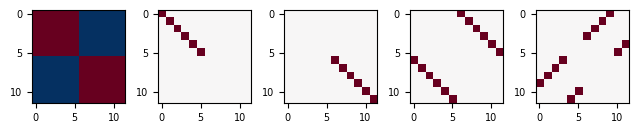

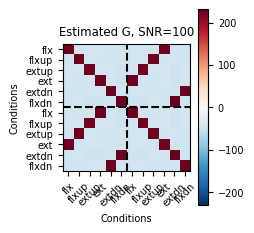

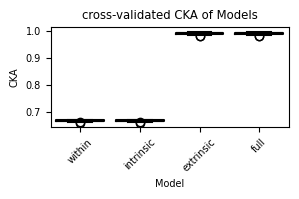

t-test intrinsic > within: t(49)=-19.933, p=1.0000
t-test extrinsic > within: t(49)=1950.210, p=0.0000
t-test full > intrinsic: t(49)=1950.207, p=0.0000
t-test full > extrinsic: t(49)=-397.043, p=1.0000


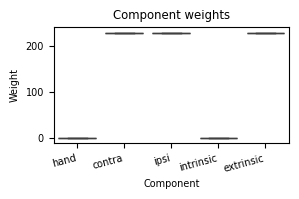

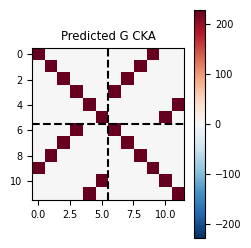

In [2]:
print('======== Intrinsic ========')
theta_true = np.array([-10e10,1,1,1,-10e10])
D, _ = utils.simulate.make_data_component_eye(sig=100, theta_true=theta_true, verbose=True)
_,_,_ = utils.simulate.cka_model_fit_eye(D, verbose=True)

print('======== Extrinsic ========')
theta_true = np.array([-10e10,1,1,-10e10,1])
D, _ = utils.simulate.make_data_component_eye(sig=100, theta_true=theta_true, verbose=True)
_,_,_ = utils.simulate.cka_model_fit_eye(D, verbose=True)



#### only intrinsic or extirnsic, low SNR

Even in very low SNR it surprisingly finds the weights nicely. However, when we do a t-test on the CKA, sometimes it can show false positive while intrinsic or extrinsic does not exist. In the cell bellow, if you run it enough, you will find those false positives. However, importantly, these false positives are when testing whether a certain relationship on top of the within strucutre adds any information. If we look at the full model family, the top of the family where we have both intrinsic and extrinsic is only significantly better than the relationship that actually does not exist.

What if both intrinsic and extrinsic existed? With equal weights and different weights?

======== Intrinsic ========


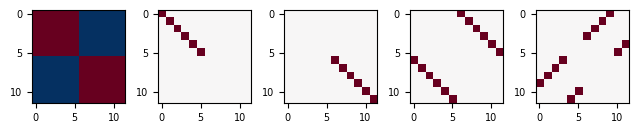

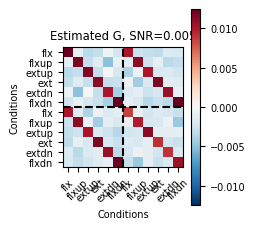

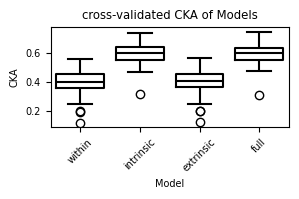

t-test intrinsic > within: t(49)=19.049, p=0.0000
t-test extrinsic > within: t(49)=7.370, p=0.0000
t-test full > intrinsic: t(49)=-0.621, p=0.7312
t-test full > extrinsic: t(49)=18.899, p=0.0000


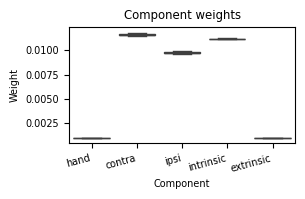

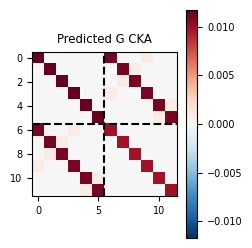

======== Extrinsic ========


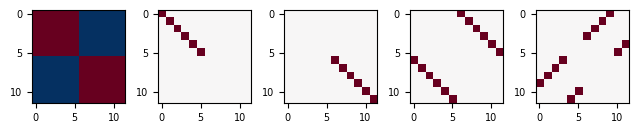

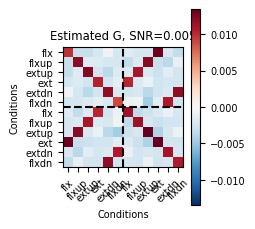

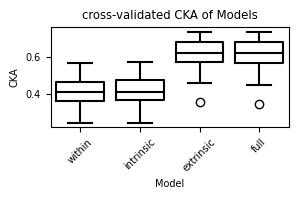

t-test intrinsic > within: t(49)=3.550, p=0.0004
t-test extrinsic > within: t(49)=16.457, p=0.0000
t-test full > intrinsic: t(49)=16.075, p=0.0000
t-test full > extrinsic: t(49)=-0.733, p=0.7665


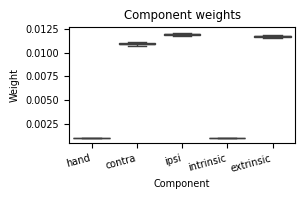

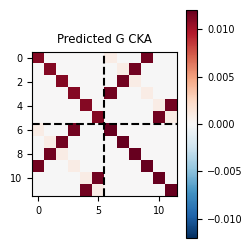

In [8]:
print('======== Intrinsic ========')
theta_true = np.array([-10e10,1,1,1,-10e10])
D, _ = utils.simulate.make_data_component_eye(sig=0.005, theta_true=theta_true, verbose=True)
_,_,_ = utils.simulate.cka_model_fit_eye(D, verbose=True)

print('======== Extrinsic ========')
theta_true = np.array([-10e10,1,1,-10e10,1])
D, _ = utils.simulate.make_data_component_eye(sig=0.005, theta_true=theta_true, verbose=True)
_,_,_ = utils.simulate.cka_model_fit_eye(D, verbose=True)



#### Both intrinsic + extrinsic, perfect SNR

Even in perfect SNR, if the extrinsic relationship is very weak while the intrinisic is very strong comparatively, it sometimes does not detect the weak relationship. So there is a false negative (almost half of the times with weights intrinsic=1 and extrinsic=-1). 

If both are equally strong or one of them is weaker but sufficiently strong, then it works fine. Still better than Pearson's r in this specific case.

======== Intrinsic ========


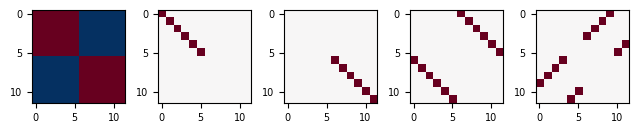

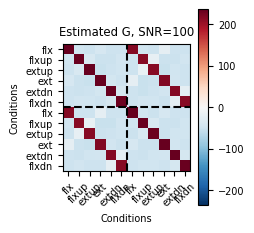

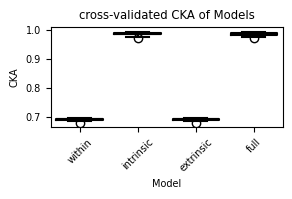

t-test intrinsic > within: t(49)=888.849, p=0.0000
t-test extrinsic > within: t(49)=1.908, p=0.0311
t-test full > intrinsic: t(49)=-9.197, p=1.0000
t-test full > extrinsic: t(49)=890.148, p=0.0000


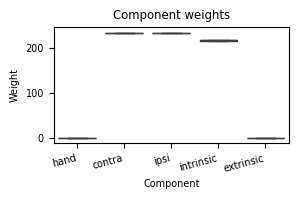

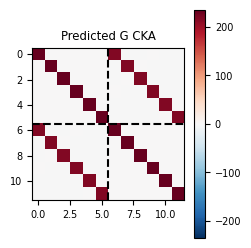

In [ ]:
theta_true = np.array([-10e10,1,1,1,-1])
D, _ = utils.simulate.make_data_component_eye(sig=100, theta_true=theta_true, verbose=True)
_,_,_ = utils.simulate.cka_model_fit_eye(D, verbose=True)



#### both intrinsic + extrinsic, low SNR

In low SNR, you can still detect both correltions similar to the high SNR case explained in the previous cell.

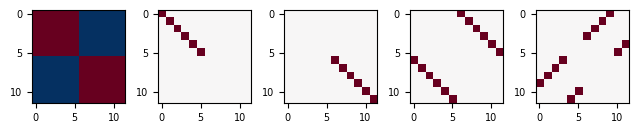

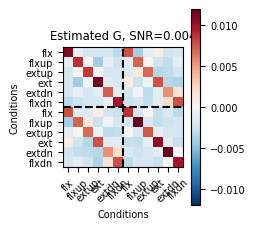

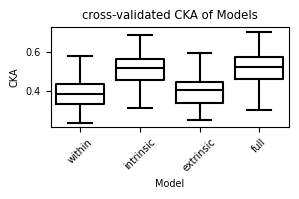

t-test intrinsic > within: t(49)=13.119, p=0.0000
t-test extrinsic > within: t(49)=2.389, p=0.0104
t-test full > intrinsic: t(49)=5.491, p=0.0000
t-test full > extrinsic: t(49)=13.514, p=0.0000


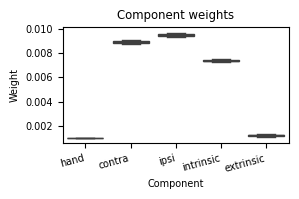

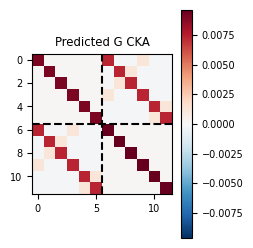

In [33]:
theta_true = np.array([-10e10,1,1,1,0])
D, _ = utils.simulate.make_data_component_eye(sig=0.004, theta_true=theta_true, verbose=True)
_,_,_ = utils.simulate.cka_model_fit_eye(D, verbose=True)



## Within = reach_return

what if the within structure was reach_return? In that case, the relationship structure would also will have the reach return in it simply because if A and B are related, then B and C are related, A and C become related. Now in that case, how would the Pearson's r and CKA perform? 

### Pearson's r

Pearon's r is similarly biased

#### perfect SNR

======== Intrinsic ========


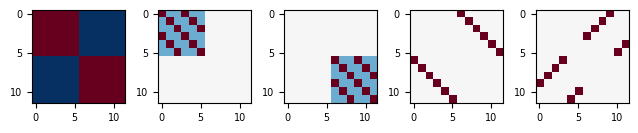

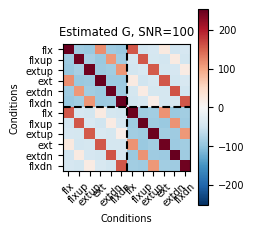

Intrinsic: mean=0.63 +/- 0.00
Extrinsic: mean=-0.08 +/- 0.01


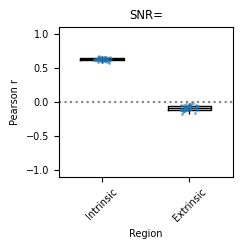

======== Extrinsic ========


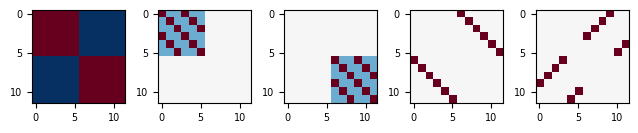

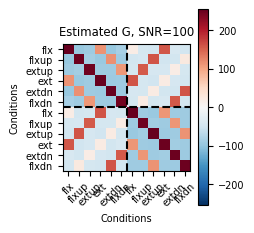

Intrinsic: mean=-0.09 +/- 0.01
Extrinsic: mean=0.63 +/- 0.00


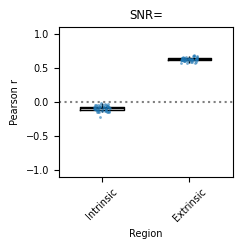

======== Intrinsic + Extrinsic ========


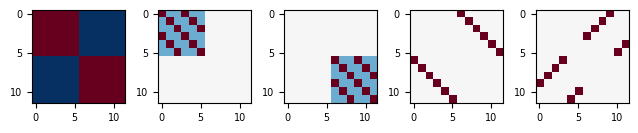

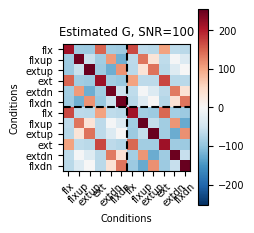

Intrinsic: mean=0.61 +/- 0.00
Extrinsic: mean=0.24 +/- 0.01


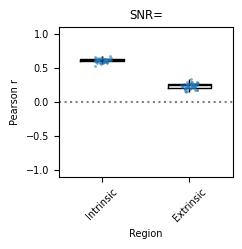

In [38]:
print('======== Intrinsic ========')
theta_true = np.array([-10e10,1,1,1,-10e10])
D, _ = utils.simulate.make_data_component_reach_return(sig=100, theta_true=theta_true, verbose=True)
_,_ = utils.simulate.pearson_r(D, verbose=True)

print('======== Extrinsic ========')
theta_true = np.array([-10e10,1,1,-10e10,1])
D, _ = utils.simulate.make_data_component_reach_return(sig=100, theta_true=theta_true, verbose=True)
_,_ = utils.simulate.pearson_r(D, verbose=True)

print('======== Intrinsic + Extrinsic ========')
theta_true = np.array([-10e10,1,1,1,0.3])
D, _ = utils.simulate.make_data_component_reach_return(sig=100, theta_true=theta_true, verbose=True)
_,_ = utils.simulate.pearson_r(D, verbose=True)



#### low SNR

======== Intrinsic ========


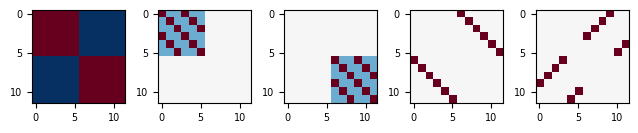

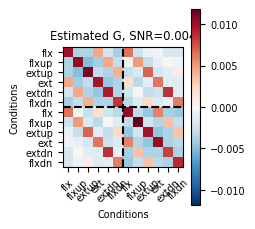

Intrinsic: mean=0.07 +/- 0.00
Extrinsic: mean=-0.01 +/- 0.00


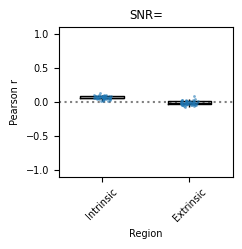

======== Extrinsic ========


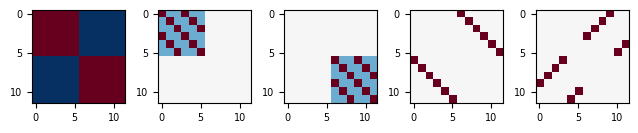

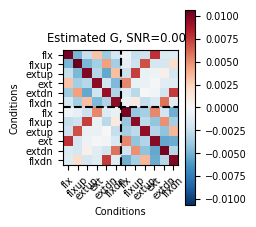

Intrinsic: mean=-0.02 +/- 0.00
Extrinsic: mean=0.07 +/- 0.00


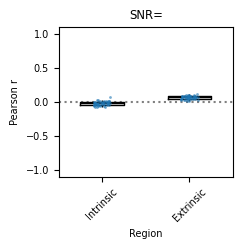

======== Intrinsic + Extrinsic ========


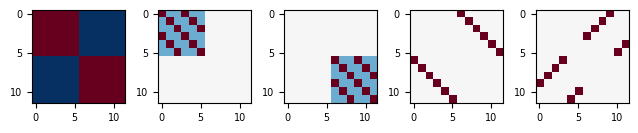

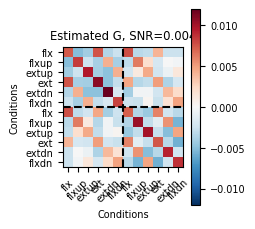

Intrinsic: mean=0.06 +/- 0.00
Extrinsic: mean=0.03 +/- 0.00


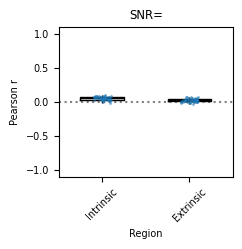

In [39]:
print('======== Intrinsic ========')
theta_true = np.array([-10e10,1,1,1,-10e10])
D, _ = utils.simulate.make_data_component_reach_return(sig=0.004, theta_true=theta_true, verbose=True)
_,_ = utils.simulate.pearson_r(D, verbose=True)

print('======== Extrinsic ========')
theta_true = np.array([-10e10,1,1,-10e10,1])
D, _ = utils.simulate.make_data_component_reach_return(sig=0.004, theta_true=theta_true, verbose=True)
_,_ = utils.simulate.pearson_r(D, verbose=True)

print('======== Intrinsic + Extrinsic ========')
theta_true = np.array([-10e10,1,1,1,0.3])
D, _ = utils.simulate.make_data_component_reach_return(sig=0.004, theta_true=theta_true, verbose=True)
_,_ = utils.simulate.pearson_r(D, verbose=True)



### CKA

#### perfect SNR

The biases are not more complicated. Because the intrinisic or extrinsnic relationship forces a strucutre in the "across" part of the G matrix, things get biased interestingly. These biases particularly depend on the covariance between reach return.

======== Intrinsic ========


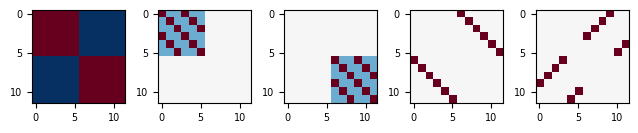

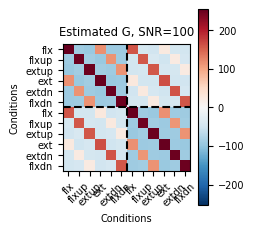

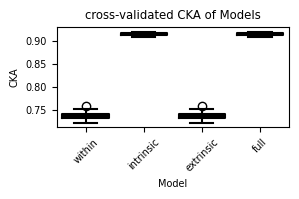

t-test intrinsic > within: t(49)=177.648, p=0.0000
t-test extrinsic > within: t(49)=2.928, p=0.0026
t-test full > intrinsic: t(49)=-7.054, p=1.0000
t-test full > extrinsic: t(49)=176.463, p=0.0000


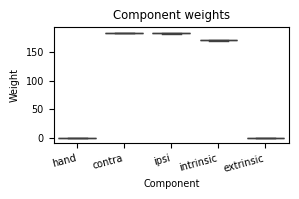

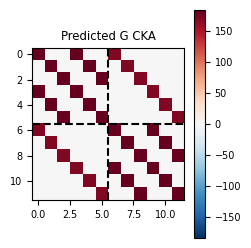

======== Extrinsic ========


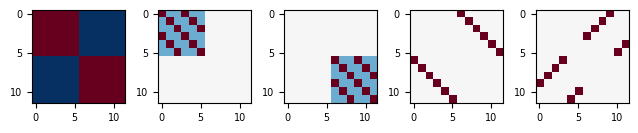

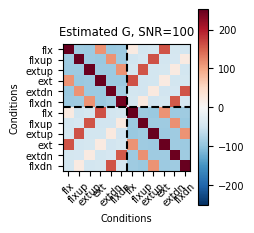

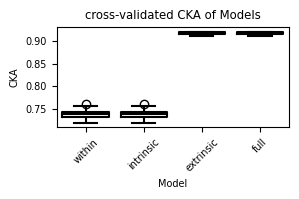

t-test intrinsic > within: t(49)=5.204, p=0.0000
t-test extrinsic > within: t(49)=153.260, p=0.0000
t-test full > intrinsic: t(49)=152.222, p=0.0000
t-test full > extrinsic: t(49)=-6.142, p=1.0000


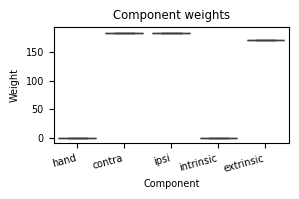

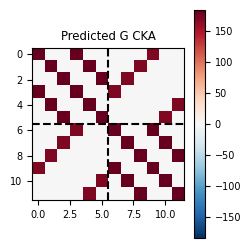

======== Intrinsic + Extrinsic ========


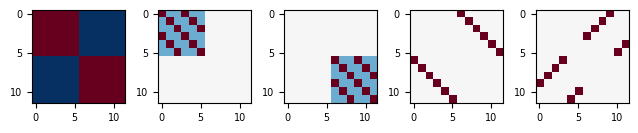

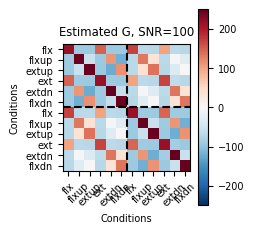

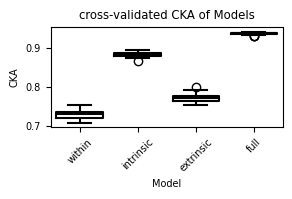

t-test intrinsic > within: t(49)=121.853, p=0.0000
t-test extrinsic > within: t(49)=50.300, p=0.0000
t-test full > intrinsic: t(49)=66.071, p=0.0000
t-test full > extrinsic: t(49)=135.138, p=0.0000


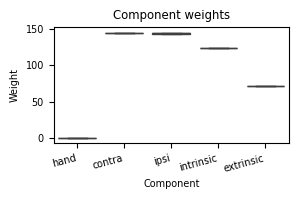

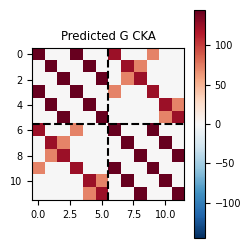

In [4]:
print('======== Intrinsic ========')
theta_true = np.array([-10e10,1,1,1,-10e10])
D, _ = utils.simulate.make_data_component_reach_return(sig=100, theta_true=theta_true, verbose=True)
_,_,_ = utils.simulate.cka_model_fit_rr(D, verbose=True)

print('======== Extrinsic ========')
theta_true = np.array([-10e10,1,1,-10e10,1])
D, _ = utils.simulate.make_data_component_reach_return(sig=100, theta_true=theta_true, verbose=True)
_,_,_ = utils.simulate.cka_model_fit_rr(D, verbose=True)

print('======== Intrinsic + Extrinsic ========')
theta_true = np.array([-10e10,1,1,1,0.3])
D, _ = utils.simulate.make_data_component_reach_return(sig=100, theta_true=theta_true, verbose=True)
_,_,_ = utils.simulate.cka_model_fit_rr(D, verbose=True)



#### low SNR

======== Intrinsic ========


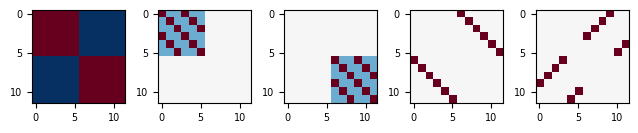

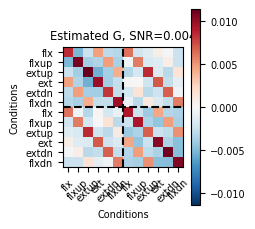

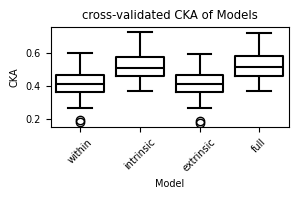

t-test intrinsic > within: t(49)=10.913, p=0.0000
t-test extrinsic > within: t(49)=0.485, p=0.3148
t-test full > intrinsic: t(49)=1.837, p=0.0362
t-test full > extrinsic: t(49)=11.268, p=0.0000


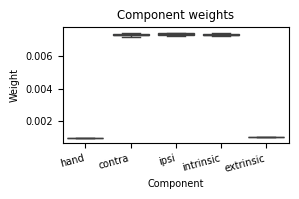

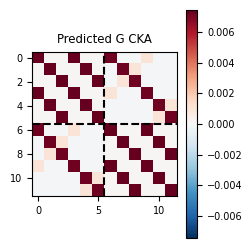

======== Extrinsic ========


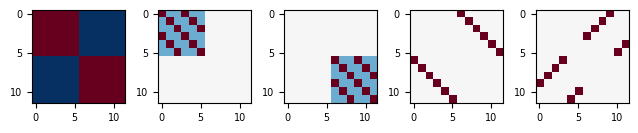

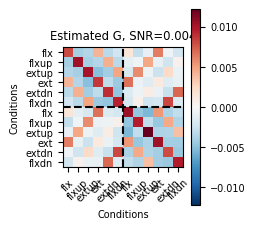

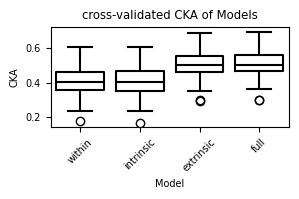

t-test intrinsic > within: t(49)=-1.018, p=0.8431
t-test extrinsic > within: t(49)=10.629, p=0.0000
t-test full > intrinsic: t(49)=10.991, p=0.0000
t-test full > extrinsic: t(49)=3.717, p=0.0003


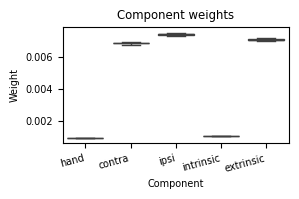

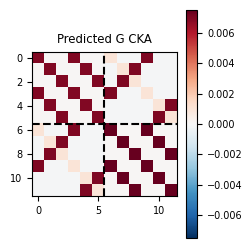

======== Intrinsic + Extrinsic ========


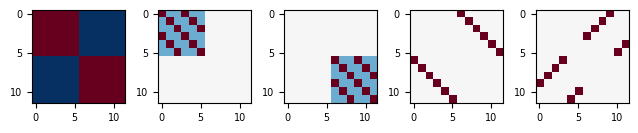

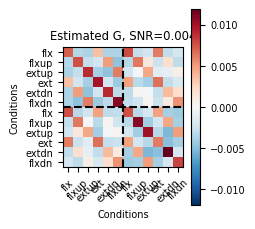

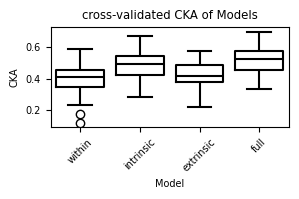

t-test intrinsic > within: t(49)=8.599, p=0.0000
t-test extrinsic > within: t(49)=5.048, p=0.0000
t-test full > intrinsic: t(49)=6.469, p=0.0000
t-test full > extrinsic: t(49)=9.800, p=0.0000


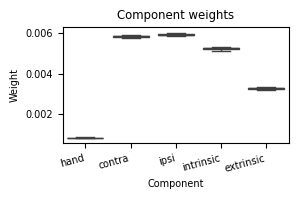

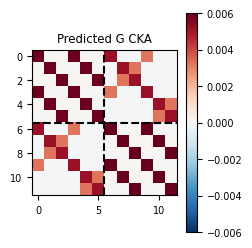

In [4]:
print('======== Intrinsic ========')
theta_true = np.array([-10e10,1,1,1,-10e10])
D, _ = utils.simulate.make_data_component_reach_return(sig=0.004, theta_true=theta_true, verbose=True)
_,_,_ = utils.simulate.cka_model_fit_rr(D, verbose=True)

print('======== Extrinsic ========')
theta_true = np.array([-10e10,1,1,-10e10,1])
D, _ = utils.simulate.make_data_component_reach_return(sig=0.004, theta_true=theta_true, verbose=True)
_,_,_ = utils.simulate.cka_model_fit_rr(D, verbose=True)

print('======== Intrinsic + Extrinsic ========')
theta_true = np.array([-10e10,1,1,1,0.3])
D, _ = utils.simulate.make_data_component_reach_return(sig=0.004, theta_true=theta_true, verbose=True)
_,_,_ = utils.simulate.cka_model_fit_rr(D, verbose=True)

